# Predicting Irrigation Need - Sulama İhtiyacını Tahmin Etme

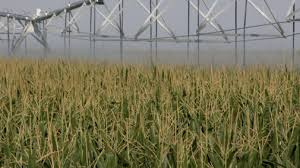

Bu projede, tarımsal sulama ihtiyacının makine öğrenmesi yöntemleri kullanılarak tahmin edilmesi amaçlanmıştır. Veri setinde yer alan sıcaklık, yağış, toprak tipi ve ürün türü gibi özellikler kullanılarak sulama seviyesi sınıflandırılmıştır. Elde edilen modelin performansı değerlendirilerek tarımsal su yönetimine katkı sağlayabilecek bir karar destek sistemi geliştirilmiştir.


### Sütun Açıklamaları

**Soil_Type:** Tarım arazisindeki toprak türünü ifade eder (Clay, Sandy, Silt vb.).

**Soil_pH:** Toprağın asitlik veya alkalilik seviyesini gösteren pH değeridir.

**Soil_Moisture:** Toprakta bulunan nem miktarını ifade eder.

**Organic_Carbon:** Topraktaki organik karbon miktarını gösterir ve toprak verimliliği hakkında bilgi verir.

**Electrical_Conductivity:** Toprağın elektriksel iletkenliğini ifade eder ve tuzluluk seviyesinin belirlenmesinde kullanılır.

**Temperature_C:** Ortam sıcaklığını santigrat derece (°C) cinsinden gösterir.

**Humidity:** Havadaki bağıl nem oranını (%) ifade eder.

**Rainfall_mm:** Belirli bir dönemde gerçekleşen yağış miktarını milimetre (mm) cinsinden gösterir.

**Sunlight_Hours:** Günlük güneşlenme süresini saat cinsinden ifade eder.

**Wind_Speed_kmh:** Rüzgar hızını kilometre/saat (km/h) cinsinden gösterir.

**Crop_Type:** Tarım arazisinde yetiştirilen ürün türünü ifade eder (Buğday, Mısır, Pamuk vb.).

**Crop_Growth_Stage:** Bitkinin büyüme ve gelişim aşamasını gösterir (Ekim, Vejetatif, Çiçeklenme, Hasat vb.).

**Season:** Tarımsal üretimin gerçekleştirildiği sezon bilgisini ifade eder.

**Irrigation_Type:** Kullanılan sulama yöntemini belirtir (Damla Sulama, Yağmurlama vb.).

**Water_Source:** Sulamada kullanılan su kaynağını ifade eder (Nehir, Rezervuar, Yeraltı Suyu vb.).

**Field_Area_hectare:** Tarım arazisinin büyüklüğünü hektar cinsinden gösterir.

**Mulching_Used:** Toprak nemini korumak amacıyla malçlama uygulamasının kullanılıp kullanılmadığını belirtir.

**Previous_Irrigation_mm:** Bir önceki sulamada verilen su miktarını milimetre (mm) cinsinden gösterir.

**Region:** Tarım arazisinin bulunduğu coğrafi bölgeyi ifade eder.

**Irrigation_Need:** Hedef değişkendir. Arazinin sulama ihtiyacını Düşük (Low), Orta (Medium) veya Yüksek (High) olarak sınıflandırır.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv


In [2]:
# Temel kütüphaneler
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarıları kapatma
import warnings
warnings.filterwarnings("ignore")

# Veri ayırma ve ölçekleme
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Değerlendirme metrikleri
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv


In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv")

df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [5]:
df.shape

(10000, 20)

In [6]:
df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 non-null  object 
 14  Water_Source           

In [8]:
df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [9]:
df.isnull().sum()



Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [10]:
df.corr(numeric_only=True)

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
Soil_pH,1.000000,-0.014067,-0.011119,0.011084,0.000129,-0.011244,0.002967,-0.009298,0.002630,0.007726,-0.000501
Soil_Moisture,-0.014067,1.000000,-0.018539,-0.020822,-0.005305,0.006601,-0.005875,0.014512,0.002960,-0.004811,-0.009195
Organic_Carbon,-0.011119,-0.018539,1.000000,0.011628,0.007155,-0.011748,-0.010832,-0.011462,0.021523,-0.024825,0.003107
Electrical_Conductivity,0.011084,-0.020822,0.011628,1.000000,-0.003715,-0.000236,-0.013536,0.003429,-0.009394,0.009923,0.010360
Temperature_C,0.000129,-0.005305,0.007155,-0.003715,1.000000,-0.008693,0.007771,0.002778,-0.008468,0.013636,0.003862
Humidity,-0.011244,0.006601,-0.011748,-0.000236,-0.008693,1.000000,-0.007395,0.016399,0.013205,0.005647,-0.002175
Rainfall_mm,0.002967,-0.005875,-0.010832,-0.013536,0.007771,-0.007395,1.000000,-0.014846,0.003926,-0.016848,0.000530
Sunlight_Hours,-0.009298,0.014512,-0.011462,0.003429,0.002778,0.016399,-0.014846,1.000000,-0.000002,-0.012491,0.002206
Wind_Speed_kmh,0.002630,0.002960,0.021523,-0.009394,-0.008468,0.013205,0.003926,-0.000002,1.000000,0.005310,-0.002884
Field_Area_hectare,0.007726,-0.004811,-0.024825,0.009923,0.013636,0.005647,-0.016848,-0.012491,0.005310,1.000000,0.014938


In [11]:
print(df["Crop_Growth_Stage"].unique())

['Vegetative' 'Flowering' 'Harvest' 'Sowing']


In [12]:
stage_mapping = {
    "Sowing": 0,
    "Vegetative": 1,
    "Flowering": 2,
    "Harvest": 3
}

df["Crop_Growth_Stage"] = df["Crop_Growth_Stage"].map(stage_mapping)

In [13]:
df["Crop_Growth_Stage"].head()

0    1
1    2
2    3
3    0
4    0
Name: Crop_Growth_Stage, dtype: int64

In [14]:
print(df["Mulching_Used"].unique())

['Yes' 'No']


In [15]:
mulching_mapping = {
    "No": 0,
    "Yes": 1
}

df["Mulching_Used"] = df["Mulching_Used"].map(mulching_mapping)

In [16]:
df["Mulching_Used"].head()

0    1
1    1
2    1
3    1
4    0
Name: Mulching_Used, dtype: int64

In [17]:
print(df["Irrigation_Need"].unique())

['Low' 'Medium' 'High']


In [18]:
target_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["Irrigation_Need"] = df["Irrigation_Need"].map(target_mapping)

In [19]:
df["Irrigation_Need"].head()

0    0
1    1
2    0
3    1
4    1
Name: Irrigation_Need, dtype: int64

In [20]:
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,1,Rabi,Rainfed,Reservoir,4.73,1,1.98,South,0
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,2,Zaid,Canal,Groundwater,12.22,1,33.56,Central,1
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,3,Rabi,Drip,Reservoir,5.52,1,34.62,South,0
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,0,Kharif,Canal,Reservoir,1.43,1,84.03,North,1
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,0,Zaid,Canal,River,2.52,0,60.86,South,1


In [21]:
df = pd.get_dummies(
    df,
    columns=[
        "Soil_Type",
        "Crop_Type",
        "Season",
        "Irrigation_Type",
        "Water_Source",
        "Region"
    ],
    drop_first=True,
    dtype=int
)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Soil_pH                    10000 non-null  float64
 1   Soil_Moisture              10000 non-null  float64
 2   Organic_Carbon             10000 non-null  float64
 3   Electrical_Conductivity    10000 non-null  float64
 4   Temperature_C              10000 non-null  float64
 5   Humidity                   10000 non-null  float64
 6   Rainfall_mm                10000 non-null  float64
 7   Sunlight_Hours             10000 non-null  float64
 8   Wind_Speed_kmh             10000 non-null  float64
 9   Crop_Growth_Stage          10000 non-null  int64  
 10  Field_Area_hectare         10000 non-null  float64
 11  Mulching_Used              10000 non-null  int64  
 12  Previous_Irrigation_mm     10000 non-null  float64
 13  Irrigation_Need            10000 non-null  int6

In [34]:
df.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Growth_Stage,...,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Region_East,Region_North,Region_South,Region_West
0,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,1,...,0,1,0,0,1,0,0,0,1,0
1,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,2,...,0,0,0,0,0,0,0,0,0,0
2,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,3,...,1,0,0,0,1,0,0,0,1,0
3,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,0,...,0,0,0,0,1,0,0,1,0,0
4,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,0,...,0,0,0,0,0,1,0,0,1,0


In [23]:
x = df.drop("Irrigation_Need", axis=1)
y = df["Irrigation_Need"]

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (8000, 33)
x_test : (2000, 33)
y_train: (8000,)
y_test : (2000,)


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier()

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.981


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier()

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.997


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression()

lr_model.fit(x_train, y_train)

y_pred_lr = lr_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.69


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier()

knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

Accuracy: 0.643


In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_model = GaussianNB()

nb_model.fit(x_train, y_train)

y_pred_nb = nb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.7835


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd

def algo_test(x, y):

    LR = LogisticRegression()
    DT = DecisionTreeClassifier()
    RF = RandomForestClassifier()
    KNN = KNeighborsClassifier()
    NB = GaussianNB()
    SVM = SVC()

    algos = [LR, DT, RF, KNN, NB, SVM]

    algo_names = [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Naive Bayes",
        "SVM"
    ]

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    accuracy = []
    precision = []
    recall = []
    f1 = []

    result = pd.DataFrame(
        columns=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],
        index=algo_names
    )

    for algo in algos:

        p = algo.fit(x_train, y_train).predict(x_test)

        accuracy.append(
            accuracy_score(y_test, p)
        )

        precision.append(
            precision_score(
                y_test,
                p,
                average="weighted"
            )
        )

        recall.append(
            recall_score(
                y_test,
                p,
                average="weighted"
            )
        )

        f1.append(
            f1_score(
                y_test,
                p,
                average="weighted"
            )
        )

    result["Accuracy"] = accuracy
    result["Precision"] = precision
    result["Recall"] = recall
    result["F1 Score"] = f1

    return result.sort_values(
        "F1 Score",
        ascending=False
    )

In [33]:
algo_test(x, y)

,Accuracy,Precision,Recall,F1 Score
Decision Tree,0.9970,0.997026,0.9970,0.997005
Random Forest,0.9765,0.977408,0.9765,0.973238
Naive Bayes,0.7835,0.779895,0.7835,0.771819
Logistic Regression,0.6900,0.660991,0.6900,0.673763
KNN,0.6430,0.626395,0.6430,0.625762
SVM,0.6340,0.607926,0.6340,0.558665


## Sonuç



Bu çalışmada, tarımsal sulama ihtiyacının tahmin edilmesi amacıyla çeşitli makine öğrenmesi algoritmaları uygulanmış ve performansları karşılaştırılmıştır. Elde edilen sonuçlara göre en başarılı model %99,7 doğruluk oranı ve 0,997 F1 skoru ile Decision Tree algoritması olmuştur. Sonuçlar, toprak özellikleri, iklim koşulları ve tarımsal parametrelerin sulama ihtiyacının belirlenmesinde önemli rol oynadığını göstermektedir. Geliştirilen model, tarımsal su kaynaklarının daha verimli kullanılmasına katkı sağlayabilecek bir karar destek sistemi olarak değerlendirilebilir.
